In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

import json
from pathlib import Path

import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import rasterio
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from estuary.util.img import (
    false_color,
)

In [3]:
skipped_regions = pd.read_csv("/Volumes/x10pro/estuary/geos/skipped_regions.csv")[
    "Site code"
].to_list()

gdf = gpd.read_file("/Users/kyledorman/data/estuary/geos/ca_data_w_usgs.geojson")
gdf = gdf[~gdf["Site code"].isin(skipped_regions)].copy()
gdf = gdf.set_index("Site code")

with open("/Users/kyledorman/data/estuary/geos/ca_empa_matching_sites.json") as f:
    matching_sites = json.load(f)

# timeseries_path = "/Users/kyledorman/data/results/estuary/train/20251114-130229/merged_all_regions_timeseries_preds.csv"
timeseries_path = (
    "/Users/kyledorman/data/results/estuary/train/20251114-130229/merged_time_series_preds.csv"
)
preds_all = pd.read_csv(Path(timeseries_path))
# normalize times
preds_all["acquired"] = (
    pd.to_datetime(preds_all["acquired"], errors="coerce", utc=True)
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
    .astype("datetime64[ns]")
)
preds_all = preds_all.sort_values("acquired").dropna(subset=["acquired"])
preds_all["y_true_prob"] = 0.05
preds_all.loc[preds_all.y_true == 1, "y_true_prob"] = 0.95

In [4]:
empa = pl.read_csv("/Volumes/x10pro/estuary/ca_all/empa/logger-raw-publish.csv")

# Normalize unit strings (strip whitespace) so comparisons match exactly
empa = empa.with_columns(
    [
        pl.col("raw_conductivity_unit")
        .cast(pl.Utf8)
        .str.strip_chars()
        .alias("raw_conductivity_unit"),
        pl.col("raw_depth_unit").cast(pl.Utf8).str.strip_chars().alias("raw_depth_unit"),
    ]
)

# Convert μS/cm → mS/cm and overwrite both columns (cast numeric first)
empa = empa.with_columns(
    [
        pl.when(pl.col("raw_conductivity_unit") == "uS/cm")
        .then(pl.col("raw_conductivity").cast(pl.Float64, strict=False) / 1000.0)
        .when(pl.col("raw_conductivity_unit") == "mS/cm")
        .then(pl.col("raw_conductivity").cast(pl.Float64, strict=False))
        .otherwise(pl.col("raw_conductivity").cast(pl.Float64, strict=False))
        .alias("raw_conductivity"),
        # Only standardize the unit to mS/cm when the original was a known conductivity unit
        pl.when(pl.col("raw_conductivity_unit").is_in(["uS/cm", "mS/cm"]))
        .then(pl.lit("mS/cm"))
        .otherwise(pl.col("raw_conductivity_unit"))
        .alias("raw_conductivity_unit"),
    ]
)

# Convert cm → m and overwrite both columns (cast numeric first)
empa = empa.with_columns(
    [
        pl.when(pl.col("raw_depth_unit") == "cm")
        .then(pl.col("raw_depth").cast(pl.Float64, strict=False) / 100.0)
        .when(pl.col("raw_depth_unit") == "m")
        .then(pl.col("raw_depth").cast(pl.Float64, strict=False))
        .otherwise(pl.col("raw_depth").cast(pl.Float64, strict=False))
        .alias("raw_depth"),
        pl.when(pl.col("raw_depth_unit").is_in(["cm", "m"]))
        .then(pl.lit("m"))
        .otherwise(pl.col("raw_depth_unit"))
        .alias("raw_depth_unit"),
    ]
)

# define time parsing (try multiple formats)
parsed_dt = pl.coalesce(
    [
        pl.col("samplecollectiontimestamp").str.strptime(
            pl.Datetime, "%d/%m/%Y %H:%M:%S", strict=False
        ),
        pl.col("samplecollectiontimestamp").str.strptime(
            pl.Datetime, "%d/%m/%Y %H:%M:%S%.f", strict=False
        ),
    ]
)

# offsets relative to UTC (Polars doesn’t know “PST/PDT” by name)
# PST = UTC−8, PDT = UTC−7
empa = empa.with_columns([parsed_dt.alias("samplecollectiontimestamp_parsed")])

# apply offset based on timezone
empa = empa.with_columns(
    [
        pl.when(pl.col("samplecollectiontimezone") == "PST")
        .then(pl.col("samplecollectiontimestamp_parsed") + pl.duration(hours=8))  # PST -> UTC
        .when(pl.col("samplecollectiontimezone") == "PDT")
        .then(pl.col("samplecollectiontimestamp_parsed") + pl.duration(hours=7))  # PDT -> UTC
        .when(pl.col("samplecollectiontimezone") == "UTC")
        .then(pl.col("samplecollectiontimestamp_parsed"))
        .otherwise(pl.col("samplecollectiontimestamp_parsed"))
        .alias("samplecollectiontimestamp_utc2")
    ]
)
empa = empa.filter(pl.col("siteid").is_in(list(matching_sites.values())))

In [5]:
empa_ranges = (
    empa.group_by(["siteid", "sensorid"])
    .agg(
        [
            pl.col("samplecollectiontimestamp_utc2").min().alias("start"),
            pl.col("samplecollectiontimestamp_utc2").max().alias("end"),
        ]
    )
    # Filter groups where (end - start) > 90 days
    .filter((pl.col("end") - pl.col("start")) > pl.duration(days=90))
    .sort(["siteid", "sensorid"])
).to_pandas()

In [6]:
empa_ranges.siteid.unique()

array(['CC-ADLC', 'CC-CAR', 'CC-PAJ', 'NC-NAV', 'SC-GOL', 'SC-MAL',
       'SC-VEN'], dtype=object)

In [7]:
SITE = "SC-VEN"
REGION = next((k for k, v in matching_sites.items() if v == SITE))

site_ranges = empa_ranges[empa_ranges["siteid"] == SITE].copy()
site_ranges["duration"] = site_ranges.end - site_ranges.start

site_ranges

,siteid,sensorid,start,end,duration
33,SC-VEN,613068,2021-11-08 20:37:00,2022-06-24 01:25:00,227 days 04:48:00
34,SC-VEN,791949,2021-03-29 23:12:00,2021-11-26 11:12:00,241 days 12:00:00
35,SC-VEN,X1683,2021-03-29 23:00:00,2022-01-22 20:54:00,298 days 21:54:00


In [8]:
site_sensor_data = empa.filter(pl.col("siteid") == SITE).filter(pl.col("sensorid") == "791949")

depth_df_orig = (
    site_sensor_data[["samplecollectiontimestamp_utc2", "raw_depth"]]
    .to_pandas()
    .rename(columns={"samplecollectiontimestamp_utc2": "acquired"})
    .sort_values(["acquired"])
)

depth_df_orig = depth_df_orig.copy()

# Ensure acquired is datetime and sorted
depth_df_orig["acquired"] = pd.to_datetime(depth_df_orig["acquired"])
depth_df_orig = depth_df_orig.sort_values("acquired").drop_duplicates("acquired")

# Set datetime index
depth_df_orig = depth_df_orig.set_index("acquired")

In [9]:
predictions = preds_all[preds_all.region == int(REGION)]
# keep preds within depth time span
predictions = predictions[
    (predictions["acquired"] >= depth_df_orig.index.min())
    & (predictions["acquired"] <= depth_df_orig.index.max())
].copy()
predictions = predictions[predictions.y_pred_unsure == 0]

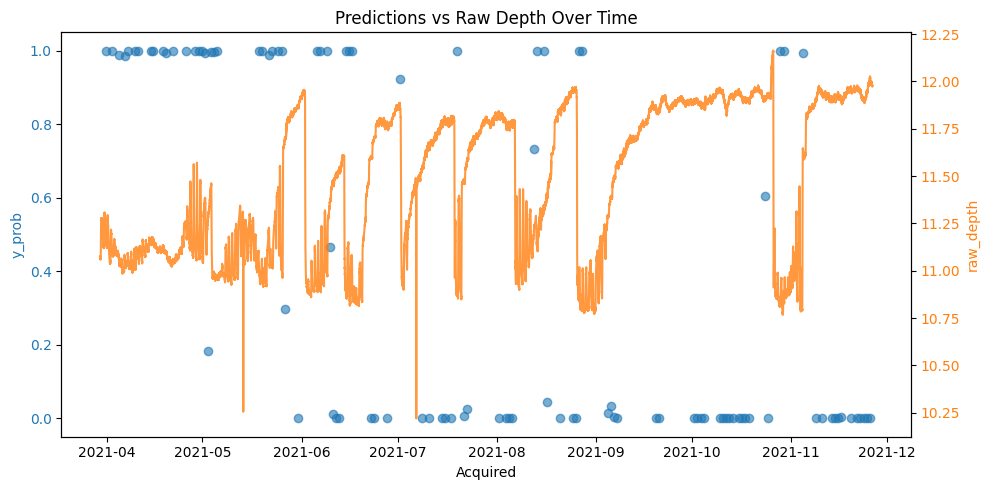

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- First y-axis: predictions ---
ax1.scatter(
    predictions["acquired"],
    predictions["y_prob"],
    color="C0",
    label="Predicted probability",
    alpha=0.6,
)
ax1.set_xlabel("Acquired")
ax1.set_ylabel("y_prob", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# --- Second y-axis ---
ax2 = ax1.twinx()
ax2.plot(depth_df_orig.index, depth_df_orig["raw_depth"], color="C1", label="Raw depth", alpha=0.8)
ax2.set_ylabel("raw_depth", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

plt.title("Predictions vs Raw Depth Over Time")
fig.tight_layout()
plt.show()

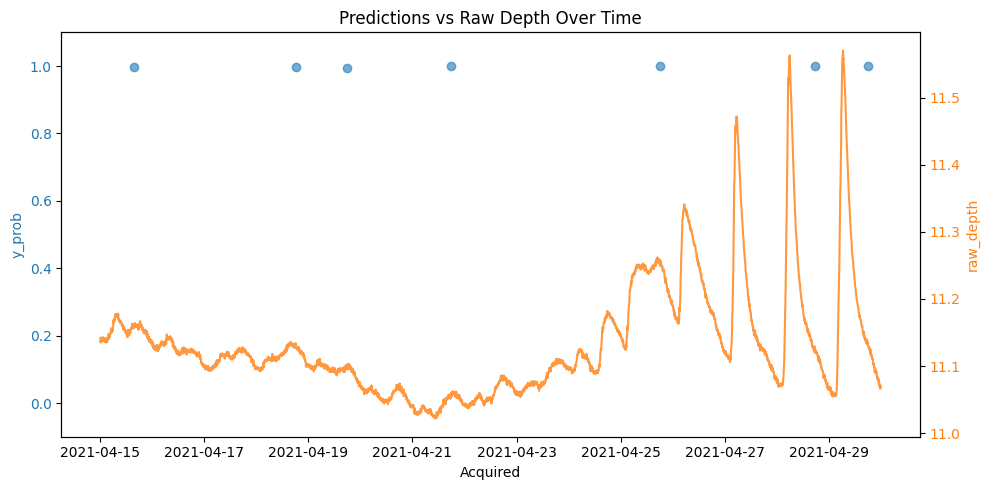

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

start = pd.Timestamp(year=2021, month=4, day=15)
end = pd.Timestamp(year=2021, month=4, day=30)

ft = depth_df_orig[(depth_df_orig.index > start) & (depth_df_orig.index < end)].reset_index()
pt = predictions[(predictions.acquired > start) & (predictions.acquired < end)]

# --- First y-axis: predictions ---
ax1.scatter(pt["acquired"], pt["y_prob"], color="C0", label="Predicted probability", alpha=0.6)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlabel("Acquired")
ax1.set_ylabel("y_prob", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# --- Second y-axis ---
ax2 = ax1.twinx()
ax2.plot(ft["acquired"], ft["raw_depth"], color="C1", label="Raw depth", alpha=0.8)
ax2.set_ylabel("raw_depth", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

plt.title("Predictions vs Raw Depth Over Time")
fig.tight_layout()
plt.show()

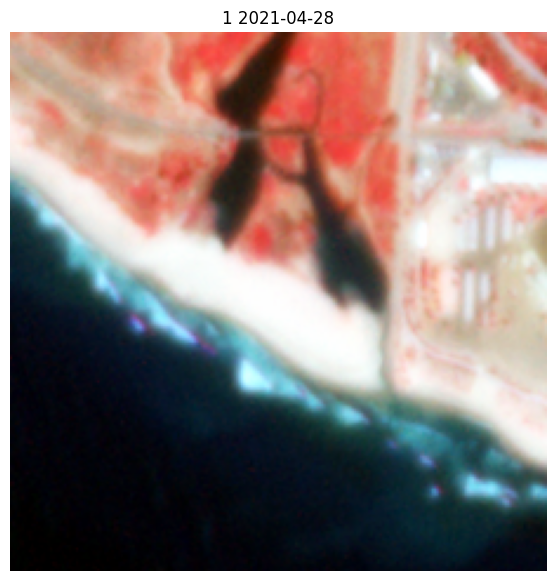

In [12]:
row = predictions[(predictions.acquired > start) & (predictions.acquired < end)].iloc[5]
plt.figure(figsize=(7, 7))
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

plt.axis("off")
plt.imshow(img)
_ = plt.title(f"{row.y_pred} {row.date}")

Number of points flagged as short drops: 6


/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_67535/1184270648.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  baseline = depth_df["raw_depth"].rolling(rolling_window, center=True, min_periods=1).median()


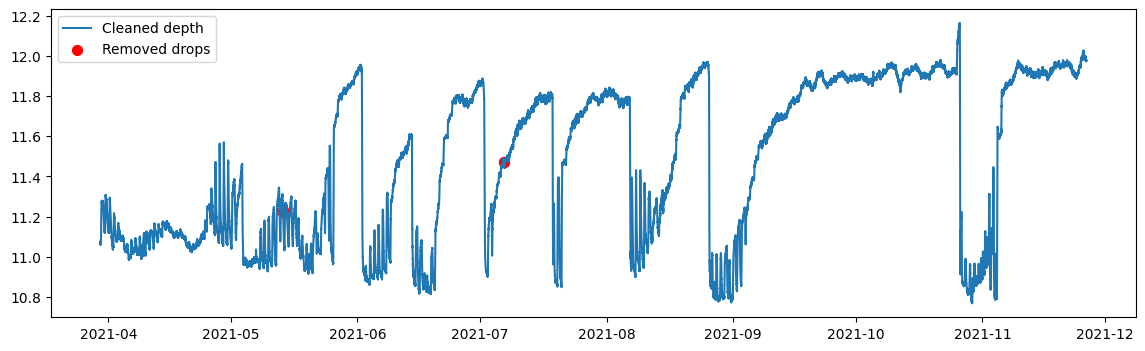

In [13]:
depth_df = depth_df_orig.copy()

# Parameters you can tune
rolling_window = "1H"  # local baseline window (1 hour)
drop_threshold = 0.2  # depth drop threshold (in same units as raw_depth)
max_len_points = 20  # max length (in samples) of a "short" invalid drop (e.g. 20 * 6min = 2h)

# 1. Rolling median baseline
baseline = depth_df["raw_depth"].rolling(rolling_window, center=True, min_periods=1).median()

# 2. Residual (how far below/above local baseline)
residual = depth_df["raw_depth"] - baseline

# 3. Boolean mask for drops: residual much LOWER than baseline
drop_mask = residual < -drop_threshold

# 4. Identify contiguous segments of drops
# Each run of True values gets a unique group id
group_id = (drop_mask != drop_mask.shift()).cumsum()

# Count length of each group
group_sizes = drop_mask.groupby(group_id).sum()  # sum works since True=1, False=0

# Find group ids representing short drop segments
short_drop_groups = group_sizes[(group_sizes > 0) & (group_sizes <= max_len_points)].index

# Final mask: only points that are part of short drop segments
short_drop_mask = drop_mask & group_id.isin(short_drop_groups)

print(f"Number of points flagged as short drops: {short_drop_mask.sum()}")

# 5. Set these to NaN
depth_df.loc[short_drop_mask, "raw_depth"] = np.nan

# 6. Interpolate over them (time-based)
depth_df["raw_depth"] = depth_df["raw_depth"].interpolate(method="time")

# Optional: sanity check plot before/after
# import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(depth_df.index, depth_df["raw_depth"], label="Cleaned depth")
ax.scatter(
    depth_df.index[short_drop_mask],
    baseline[short_drop_mask],
    color="red",
    s=50,
    label="Removed drops",
)
ax.legend()
plt.show()

In [14]:
depth_df = depth_df.copy()

# Build a regular 6-minute grid from start to end
full_index = pd.date_range(
    start=depth_df.index.min(),
    end=depth_df.index.max(),
    freq="6T",  # 6-minute interval
)

# Reindex onto the regular grid
depth_df = depth_df.reindex(full_index)

# Time-based interpolation for raw_depth
depth_df["raw_depth"] = depth_df["raw_depth"].interpolate(method="time")

# Clean up index name
depth_df.index.name = "acquired"

# Optional: quick sanity check
depth_df.head(), depth_df.tail()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_67535/1209708452.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(


(                     raw_depth
 acquired                      
 2021-03-29 23:12:00     11.075
 2021-03-29 23:18:00     11.077
 2021-03-29 23:24:00     11.077
 2021-03-29 23:30:00     11.073
 2021-03-29 23:36:00     11.074,
                      raw_depth
 acquired                      
 2021-11-26 10:48:00     11.978
 2021-11-26 10:54:00     11.973
 2021-11-26 11:00:00     11.976
 2021-11-26 11:06:00     11.972
 2021-11-26 11:12:00     11.976)

In [15]:
import numpy as np
import pandas as pd

# ---------- Helper feature functions ----------


def acf_at_lag(arr, lag):
    """Simple autocorrelation at a given lag."""
    if lag <= 0 or len(arr) <= lag:
        return np.nan
    x0 = arr[:-lag]
    x1 = arr[lag:]
    if x0.std() == 0 or x1.std() == 0:
        return np.nan
    return np.corrcoef(x0, x1)[0, 1]


def compute_basic_stats(s, ts_median):
    """Range, variance, slope, derivative stats, and window min/max."""
    s = s.dropna()
    if len(s) < 5:
        return {}

    # window min & max
    win_min = s.min()
    win_max = s.max()

    # range and variance
    rng = win_max - win_min
    var = s.var()

    # slope (linear trend)
    x = s.index.view(int)  # nanoseconds
    y = s.values
    slope = np.polyfit(x, y, 1)[0]

    # absolute derivative stats
    d = s.diff().dropna()
    abs_deriv_mean = np.abs(d).mean()
    abs_deriv_max = np.abs(d).max()

    # Median raw value relative to the global median
    median_offset = np.median(s - ts_median)

    return {
        "win_min": win_min,
        "win_max": win_max,
        "range": rng,
        "variance": var,
        "mean_slope": slope,
        "abs_deriv_mean": abs_deriv_mean,
        "abs_deriv_max": abs_deriv_max,
        "median_offset": median_offset,
    }


def compute_acf_features(s, dt_min):
    """ACF at 1-sample, ~6h, and ~12h lags."""
    s = s.dropna()
    if len(s) < 5 or dt_min <= 0:
        return {"autocorr_lag1": np.nan, "acf_6h": np.nan, "acf_12h": np.nan}

    arr = s.values

    acf1 = acf_at_lag(arr, 1)

    lag_6h_samples = int(round(6.21 * 60 / dt_min))
    lag_12h_samples = int(round(12.42 * 60 / dt_min))
    lag_24h_samples = int(round(24.84 * 60 / dt_min))

    acf_6h = acf_at_lag(arr, lag_6h_samples) if lag_6h_samples > 0 else np.nan
    acf_12h = acf_at_lag(arr, lag_12h_samples) if lag_12h_samples > 0 else np.nan
    acf_24h = acf_at_lag(arr, lag_24h_samples) if lag_24h_samples > 0 else np.nan

    return {
        "autocorr_lag1": acf1,
        "acf_6h": acf_6h,
        "acf_12h": acf_12h,
        "acf_24h": acf_24h,
    }


def compute_spectral_features(s, dt_min):
    """Tidal power ratio from FFT (~0.8–3 cycles/day)."""
    s = s.dropna()
    if len(s) < 5 or dt_min <= 0:
        return {"tidal_power_ratio": np.nan}

    y = s.values - s.values.mean()
    N = len(y)
    if N <= 4:
        return {"tidal_power_ratio": np.nan}

    dt_hours = dt_min / 60.0
    freqs_cph = np.fft.rfftfreq(N, d=dt_hours)
    freqs_cpd = freqs_cph * 24.0
    amps = np.abs(np.fft.rfft(y)) ** 2

    tidal_band = (freqs_cpd >= 0.8) & (freqs_cpd <= 3.0)
    tidal_power = amps[tidal_band].sum()
    total_power = amps[1:].sum()  # exclude DC

    if total_power > 0:
        tpr = tidal_power / total_power
    else:
        tpr = np.nan

    return {"tidal_power_ratio": tpr}


def compute_turning_points(s):
    """Number of turning points (wiggles) as a crude periodicity proxy."""
    s = s.dropna()
    if len(s) < 5:
        return {"turning_points": np.nan}

    s_smooth = s.rolling(window=3, center=True, min_periods=1).mean().values
    diff1 = np.diff(s_smooth)
    sign = np.sign(diff1)
    turning_points = np.sum(np.diff(sign) != 0)

    return {"turning_points": turning_points}


def compute_features_for_window(s, ts_median, base_freq="6min"):
    """
    Given a raw_depth slice (Series), resample to uniform base_freq
    and compute all feature sets.
    """
    s = s.dropna()
    if len(s) < 5:
        return None

    # resample to uniform interval for spectral + ACF
    s = s.resample(base_freq).interpolate("time").dropna()
    if len(s) < 5:
        return None

    # sampling interval in minutes
    dt_min = np.median(np.diff(s.index.values).astype("timedelta64[m]").astype(float))
    if dt_min <= 0:
        dt_min = np.nan

    feats = {}
    feats.update(compute_basic_stats(s, ts_median))
    feats.update(compute_acf_features(s, dt_min))
    feats.update(compute_spectral_features(s, dt_min))
    feats.update(compute_turning_points(s))

    cf = features_1d.copy()

    return feats


# ---------- Generic overlapping window extractor ----------


def extract_windowed_features(depth_df, window_size="1D", step="1D", base_freq="6min", prefix=""):
    """
    Extract features on sliding windows.

    window_size : e.g. '1D' or '3D'
    step        : how far to move each window, e.g. '1D'
    prefix      : string to prepend to feature names, e.g. 'd1_' or 'd3_'

    Each row is timestamped by the window end time.
    """
    df = depth_df.copy().sort_index()
    start = df.index.min()
    end = df.index.max()

    window_delta = pd.Timedelta(window_size)
    step_delta = pd.Timedelta(step)

    rows = []
    t = start + window_delta  # first window end

    ts_median = df.raw_depth.median()

    while t <= end:
        s = df.loc[t - window_delta : t, "raw_depth"]
        feats = compute_features_for_window(s, ts_median=ts_median, base_freq=base_freq)
        if feats is not None:
            # add timestamp + prefix feature names
            row = {"timestamp": t}
            for k, v in feats.items():
                row[prefix + k] = v
            rows.append(row)

        t += step_delta

    features = pd.DataFrame(rows).set_index("timestamp")

    # how today's min compares to yesterday's (closure / perched signal)
    features[f"{prefix}min_diff"] = features[f"{prefix}win_min"].diff()
    features[f"{prefix}min_diff_smooth"] = (
        features[f"{prefix}min_diff"].rolling(3, center=True, min_periods=1).mean()
    )

    # how much today's max exceeds yesterday's min (breach signal)
    features[f"{prefix}max_minus_prev_min"] = features[f"{prefix}win_max"] - features[
        f"{prefix}win_min"
    ].shift(1)

    return features

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def minmax_norm(s):
    s = s.astype(float)
    s_min = s.min()
    s_max = s.max()
    if s_max == s_min:
        return pd.Series(0.5, index=s.index)  # flat if constant
    return (s - s_min) / (s_max - s_min)


def plot_features_with_depth(depth_df, feature_df, feature_cols, title=""):
    """
    Plot raw water depth and a set of normalized features on the same time axis.

    depth_df   : full-resolution water level (index = datetime, col 'raw_depth')
    feature_df : windowed features (index = timestamps of windows)
    feature_cols : list of column names from feature_df to plot
    """

    # Align depth to feature timestamps (e.g. daily/window end)
    depth_at_features = depth_df["raw_depth"].reindex(feature_df.index, method="nearest")

    # Normalize each feature to [0, 1]
    norm_features = feature_df[feature_cols].apply(minmax_norm)

    fig, ax_depth = plt.subplots(figsize=(16, 5))

    # --- Water depth (left axis) ---
    ax_depth.plot(
        depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Raw Depth"
    )
    ax_depth.set_ylabel("Raw Depth", color="black")
    ax_depth.tick_params(axis="y", labelcolor="black")

    # --- Normalized features (right axis) ---
    ax_feat = ax_depth.twinx()
    colors = plt.cm.tab10(np.linspace(0, 1, len(feature_cols)))

    for col, c in zip(feature_cols, colors):
        ax_feat.plot(
            norm_features.index,
            norm_features[col],
            label=col,
            color=c,
            linewidth=1.2,
        )

    ax_feat.set_ylabel("Normalized feature value (0–1)")
    ax_feat.set_ylim(-0.05, 1.05)

    # Title & legend
    ax_depth.set_title(title)
    lines1, labels1 = ax_depth.get_legend_handles_labels()
    lines2, labels2 = ax_feat.get_legend_handles_labels()
    ax_feat.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

In [17]:
# 1-day windows, sliding 1 day
features_1d = extract_windowed_features(
    depth_df, window_size="24h", step="24h", base_freq="6min", prefix="d1_"
)

# 3-day windows, sliding 1 day
features_3d = extract_windowed_features(
    depth_df, window_size="3D", step="24h", base_freq="6min", prefix="d3_"
)

# Combine: only keep timestamps where both exist
daily_features = pd.concat([features_1d, features_3d], axis=1, join="inner")

# daily_features = features_3d

daily_features.head()

NameError: name 'features_1d' is not defined

In [18]:
import numpy as np
import pandas as pd


def rolling_tidal_acf(depth_series, lag_hours, window_days=3, smooth_hours=1):
    """
    Compute rolling tidal autocorrelation at a given lag (in hours),
    with smoothing and detrending inside each rolling window.

    depth_series : pd.Series with regular sampling (e.g. 6 min)
    lag_hours    : float, lag in hours (e.g. 6.21, 12.42, 24.84)
    window_days  : int or float, length of rolling window in days
    smooth_hours : float, length of inner smoothing window in hours
    """

    # Infer sampling interval in minutes
    dt_min = np.median(np.diff(depth_series.index.values).astype("timedelta64[m]").astype(float))
    if dt_min <= 0:
        raise ValueError("Non-positive dt_min; check your index spacing.")

    # Convert to samples
    lag_samples = int(round(lag_hours * 60.0 / dt_min))
    window_samples = int(round(window_days * 24 * 60.0 / dt_min))
    smooth_samples = max(1, int(round(smooth_hours * 60.0 / dt_min)))

    if lag_samples >= window_samples:
        raise ValueError("Lag is too large relative to window length.")

    arr = depth_series.values

    def _acf_in_window(window_arr):
        # window_arr is a 1D numpy array of length window_samples
        if np.isnan(window_arr).sum() > 0:
            return np.nan

        n = len(window_arr)
        if n <= lag_samples * 2:
            return np.nan

        # 1) smooth with moving average
        if smooth_samples > 1:
            kernel = np.ones(smooth_samples) / smooth_samples
            sm = np.convolve(window_arr, kernel, mode="same")
        else:
            sm = window_arr

        # 2) detrend (linear)
        x = np.arange(n)
        coeffs = np.polyfit(x, sm, 1)
        trend = np.polyval(coeffs, x)
        detrended = sm - trend

        # 3) compute autocorr at lag_samples
        y0 = detrended[:-lag_samples]
        y1 = detrended[lag_samples:]

        if y0.std() == 0 or y1.std() == 0:
            return np.nan

        return np.corrcoef(y0, y1)[0, 1]

    # Rolling apply over window_samples
    acf_series = depth_series.rolling(window=window_samples, min_periods=window_samples // 2).apply(
        _acf_in_window, raw=True
    )

    return acf_series


# -----------------------------
# Use it for your three tidal lags
# -----------------------------
depth_series = depth_df["raw_depth"].sort_index()

acf_6h = rolling_tidal_acf(depth_series, lag_hours=6.21, window_days=24.84 * 3 / 24, smooth_hours=1)
acf_12h = rolling_tidal_acf(
    depth_series, lag_hours=12.42, window_days=24.84 * 3 / 24, smooth_hours=1
)
acf_24h = rolling_tidal_acf(
    depth_series, lag_hours=24.84, window_days=24.84 * 3 / 24, smooth_hours=1
)

acf_df = pd.DataFrame(
    {
        "acf_6h": acf_6h,
        "acf_12h": acf_12h,
        "acf_24h": acf_24h,
    }
)
acf_df["acf_6h_acf_12h"] = acf_df.acf_12h - acf_df.acf_6h
acf_df["acf_6h_acf_24h"] = acf_df.acf_24h - acf_df.acf_6h
acf_df["acf_12h_acf_24h"] = acf_df.acf_24h - acf_df.acf_12h
acf_df["acf_6h_acf_12h_acf_24h"] = acf_df.acf_24h + acf_df.acf_12h - (2 * acf_df.acf_6h)
acf_df.head()

,acf_6h,acf_12h,acf_24h,acf_6h_acf_12h,acf_6h_acf_24h,acf_12h_acf_24h,acf_6h_acf_12h_acf_24h
acquired,,,,,,,
2021-03-29 23:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-29 23:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-29 23:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-29 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-29 23:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


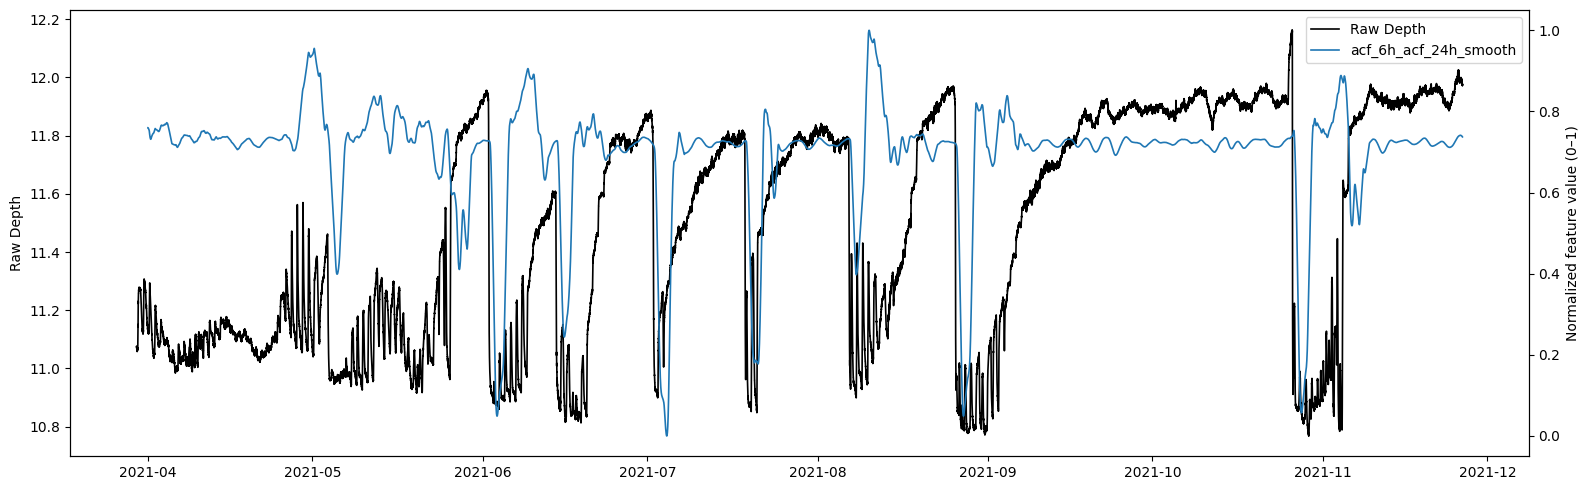

In [19]:
strength = acf_df["acf_6h_acf_24h"]

# e.g. 12-hour or 24-hour rolling mean
acf_df["acf_6h_acf_24h_smooth"] = strength.rolling("24h", min_periods=2).mean()

plot_features_with_depth(
    depth_df,
    acf_df,
    feature_cols=["acf_6h_acf_24h_smooth"],
)

In [20]:
import numpy as np
import pandas as pd


def find_tidal_turns(depth_series, smooth_window="1H", resample_rule="1H", slope_threshold=0.001):
    """
    Find tidal-scale turning points (highs and lows) in a full-depth time series.

    Parameters
    ----------
    depth_series : pd.Series
        Indexed by datetime (e.g. depth_df['raw_depth']).
    smooth_window : str
        Rolling window for smoothing (e.g. '1H', '2H').
    resample_rule : str
        Resampling rule to coarsen the time grid (e.g. '1H', '30min').
    slope_threshold : float
        Minimum absolute slope (in depth units per step) to treat as "real" slope.

    Returns
    -------
    turns_idx : DatetimeIndex
        Timestamps where a major turning point is detected.
    """

    s = depth_series.sort_index().copy()

    # 1) Smooth within about 1 hour to kill high-frequency noise
    s_smooth = s.rolling(smooth_window, center=True, min_periods=1).mean()

    # 2) Downsample to a coarser grid
    s_resampled = s_smooth.resample(resample_rule).mean().dropna()

    # 3) First difference and its sign
    diff1 = s_resampled.diff()
    # ignore tiny slopes
    diff1_filtered = diff1.copy()
    diff1_filtered[np.abs(diff1_filtered) < slope_threshold] = 0.0

    sign = np.sign(diff1_filtered)

    # 4) Turning points = where sign changes from + to - or - to +
    # ignore transitions involving zeros (flat segments)
    sign_shift = sign.shift(1)
    turn_mask = (sign != 0) & (sign_shift != 0) & (sign != sign_shift)

    turns_idx = s_resampled.index[turn_mask]

    return turns_idx


tidal_turns = find_tidal_turns(
    depth_df["raw_depth"],
    smooth_window="1h",
    resample_rule="3h",
    slope_threshold=0.005,  # tune this
)

In [21]:
# Boolean / 0-1 series at full resolution
turn_flags = pd.Series(0, index=depth_df.index, dtype=int)

# Map each turning time to nearest timestamp in depth_df
nearest_idx = depth_df.index.get_indexer(tidal_turns, method="nearest")
turn_flags.iloc[nearest_idx] = 1

# Rolling count of turns (e.g. per 1 day)
rolling_window = "3D"  # or "3D" etc.
turn_count = turn_flags.rolling(rolling_window).sum()

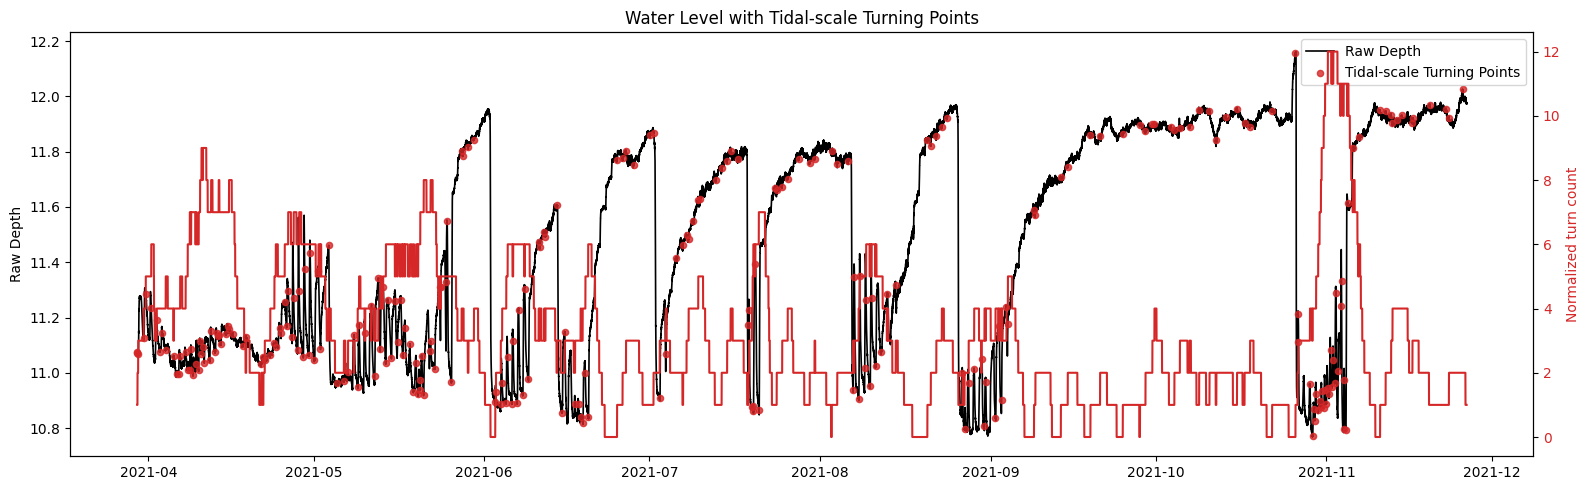

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Raw Depth")

if len(tidal_turns) > 0:
    ax.scatter(
        tidal_turns,
        depth_df["raw_depth"].reindex(tidal_turns, method="nearest"),
        color="C3",
        s=20,
        label="Tidal-scale Turning Points",
        alpha=0.8,
        zorder=5,
    )

# Rolling turn count (normalized) on right axis
ax2 = ax.twinx()
ax2.plot(
    turn_count.index,
    turn_count.values,
    color="C3",
    linewidth=1.5,
    label=f"Turn count ({rolling_window} window, normalized)",
)
ax2.set_ylabel("Normalized turn count", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")

ax.set_ylabel("Raw Depth")
ax.set_title("Water Level with Tidal-scale Turning Points")
ax.legend()
plt.tight_layout()
plt.show()

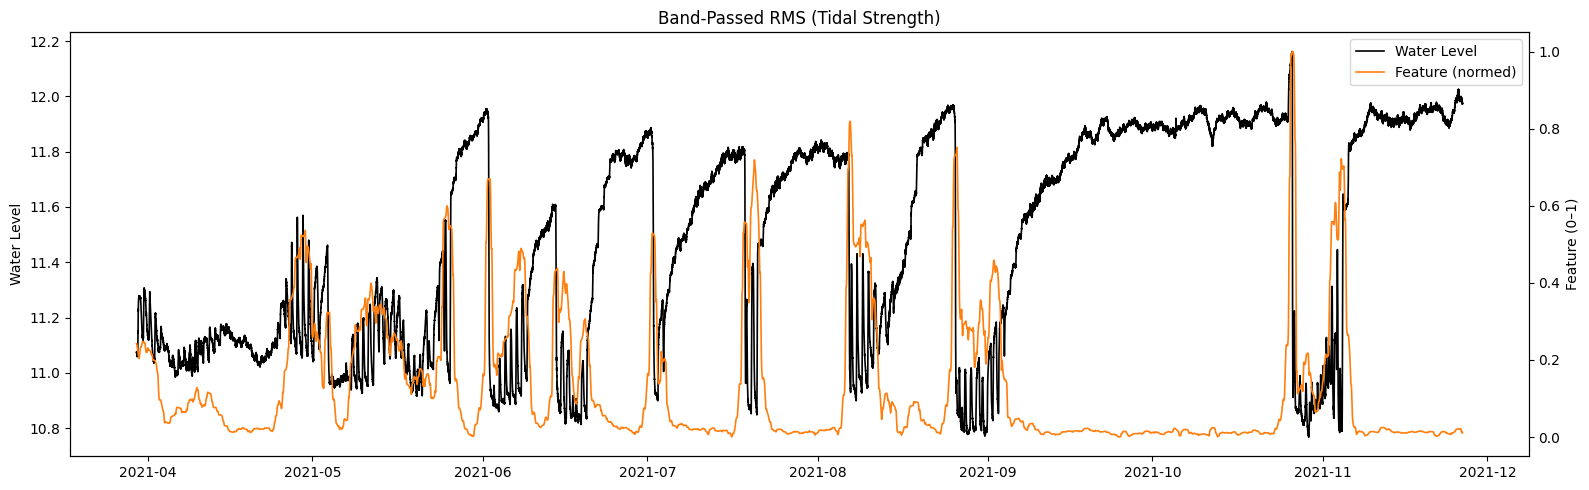

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt


def plot_feature_with_depth(depth_df, feature_series, title):
    fig, ax1 = plt.subplots(figsize=(16, 5))

    # water level
    ax1.plot(
        depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Water Level"
    )
    ax1.set_ylabel("Water Level")

    # normalized feature on 2nd axis
    ax2 = ax1.twinx()
    f = feature_series.copy()
    f = (f - f.min()) / (f.max() - f.min())  # normalize
    ax2.plot(f.index, f, color="C1", linewidth=1.2, label="Feature (normed)")
    ax2.set_ylabel("Feature (0–1)")
    ax2.set_ylim(-0.05, 1.05)

    # legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()


def bandpass_tidal_rms(depth_df, low_cpd=0.7, high_cpd=3.5, rolling_time="6h"):
    s = depth_df["raw_depth"].dropna()

    # sampling interval
    dt_min = np.median(np.diff(s.index.values).astype("timedelta64[m]").astype(float))
    fs = 60.0 / dt_min  # samples per hour
    fs_per_day = 24 * fs

    # convert cutoff frequencies in cycles/day to Nyquist-normalized frequency
    nyq = 0.5 * fs_per_day
    low = low_cpd / nyq
    high = high_cpd / nyq

    b, a = butter(4, [low, high], btype="band")
    filtered = filtfilt(b, a, s.values)

    # rolling RMS (3h or 6h)
    rms = (
        pd.Series(filtered, index=s.index)
        .rolling(rolling_time, center=True)
        .apply(lambda x: np.sqrt(np.mean(x**2)))
    )
    return rms


rms_tidal = bandpass_tidal_rms(depth_df, rolling_time="24h")
# var = depth_df["raw_depth"].rolling("24h", center=True).var()

# rms_tidal[var > var.quantile(0.98)] = 0.0
plot_feature_with_depth(depth_df, rms_tidal, "Band-Passed RMS (Tidal Strength)")

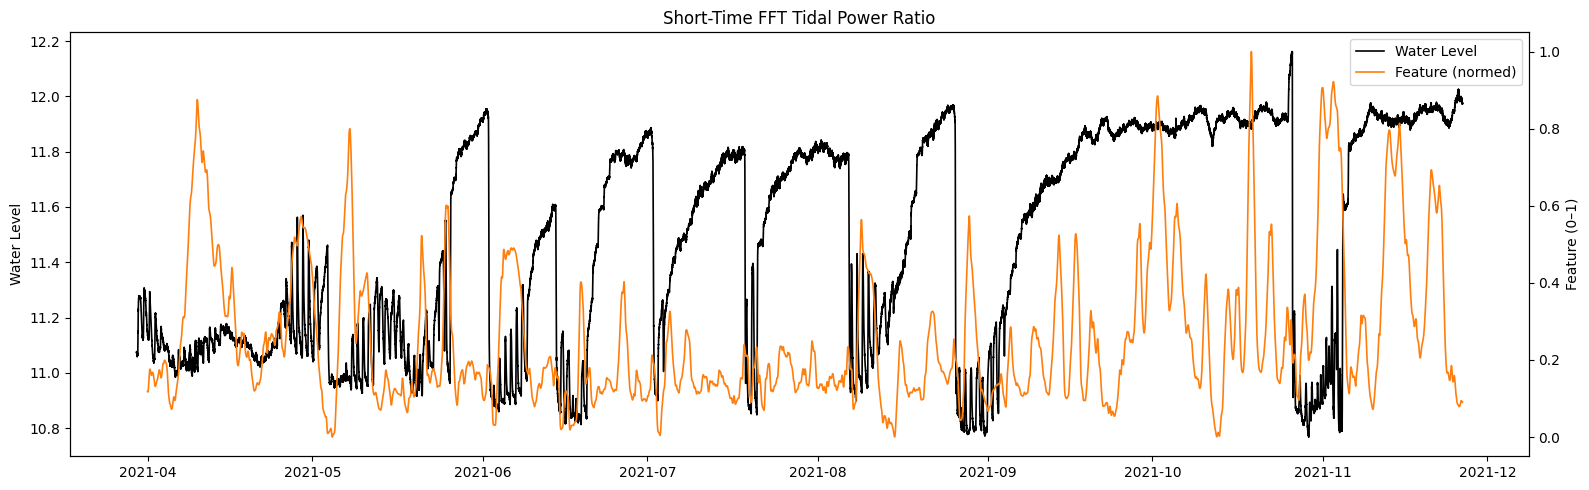

In [30]:
def stft_tidal_power(depth_df, window_hours=48):
    s = depth_df["raw_depth"].dropna()

    dt_min = np.median(np.diff(s.index.values).astype("timedelta64[m]").astype(float))
    dt_hr = dt_min / 60
    window_samples = int(window_hours / dt_hr)

    power_list = []
    idx_list = []

    for i in range(window_samples, len(s)):
        window_slice = s.values[i - window_samples : i]
        y = window_slice - np.mean(window_slice)

        freqs = np.fft.rfftfreq(window_samples, d=dt_hr)
        cpd = freqs * 24
        amps = np.abs(np.fft.rfft(y)) ** 2

        # tidal band
        mask = (cpd >= 2) & (cpd <= 4)
        tidal_power = amps[mask].sum()
        total_power = amps[1:].sum()

        ratio = tidal_power / total_power if total_power > 0 else np.nan
        power_list.append(ratio)
        idx_list.append(s.index[i])

    return pd.Series(power_list, index=idx_list)


tpr_series = stft_tidal_power(depth_df).rolling("1D", center=True).mean()
plot_feature_with_depth(depth_df, tpr_series, "Short-Time FFT Tidal Power Ratio")

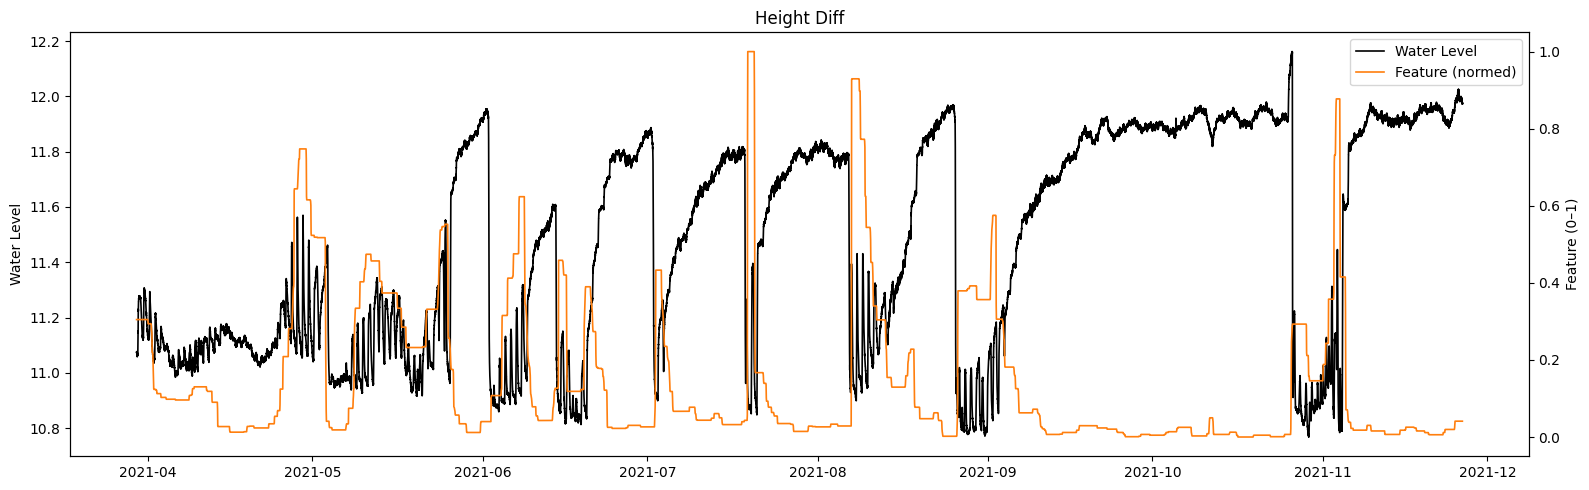

In [63]:
def normalize(x):
    xm = x.mean()
    xs = x.std()
    return (x - xm) / xs


dmin = depth_df["raw_depth"].rolling("36h", center=True).quantile(0.01)
dmax = depth_df["raw_depth"].rolling("36h", center=True).quantile(0.99)
d_diff = dmax - dmin
d_tide = d_diff.rolling("3D", center=True).quantile(0.01).rolling("12h", center=True).quantile(0.99)

plot_feature_with_depth(depth_df, d_tide.resample("1h").max(), "Height Diff")

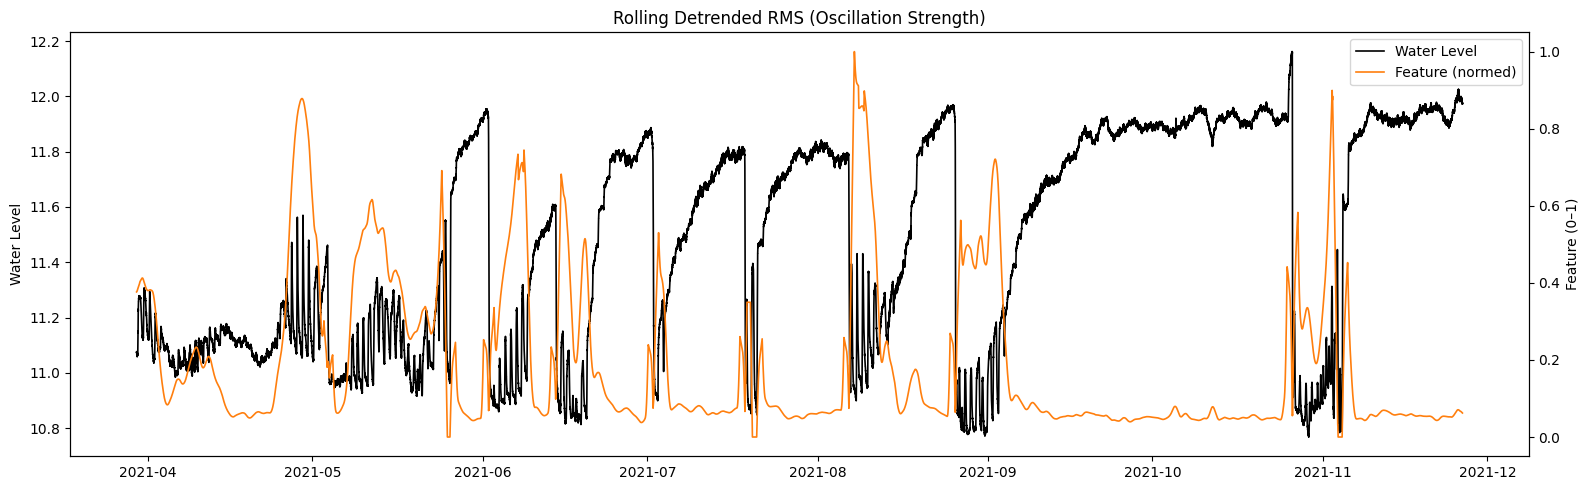

In [355]:
def detrended_rms(depth_df, window="12h"):
    s = depth_df["raw_depth"].dropna()

    def detrend_rms(x):
        if len(x) < 5:
            return np.nan
        x = np.array(x)
        t = np.arange(len(x))
        coeff = np.polyfit(t, x, 1)
        detr = x - np.polyval(coeff, t)
        return np.sqrt(np.mean(detr**2))

    return s.rolling(window, center=True).apply(detrend_rms, raw=False)


d_rms = detrended_rms(depth_df, window="24h").rolling("24h", center=True).mean()
var = depth_df["raw_depth"].rolling("24h", center=True).var()

d_rms[var > var.quantile(0.95)] = 0.0
plot_feature_with_depth(
    depth_df,
    d_rms.rolling("24h", center=True).mean(),
    "Rolling Detrended RMS (Oscillation Strength)",
)

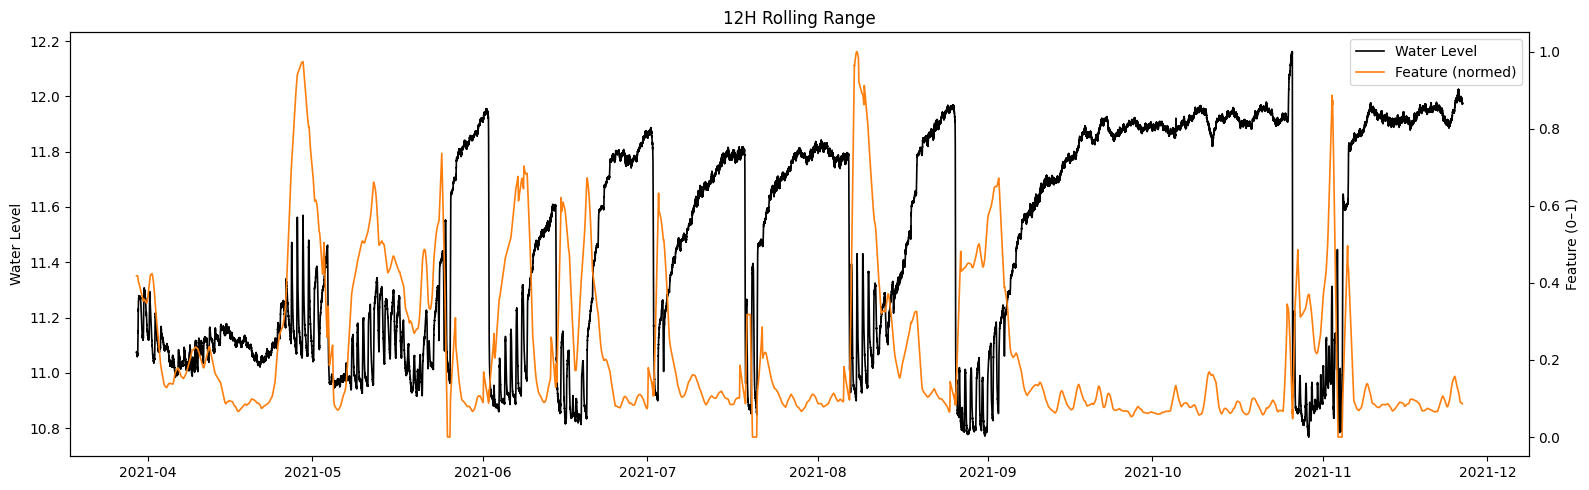

In [353]:
range12 = depth_df["raw_depth"].rolling("24h", center=True).apply(lambda x: x.max() - x.min())
var = depth_df["raw_depth"].rolling("24h", center=True).var()

range12[var > var.quantile(0.95)] = 0.0
range_var = minmax_norm(range12) - minmax_norm(var)
plot_feature_with_depth(depth_df, range12.rolling("24h", center=True).mean(), "12H Rolling Range")

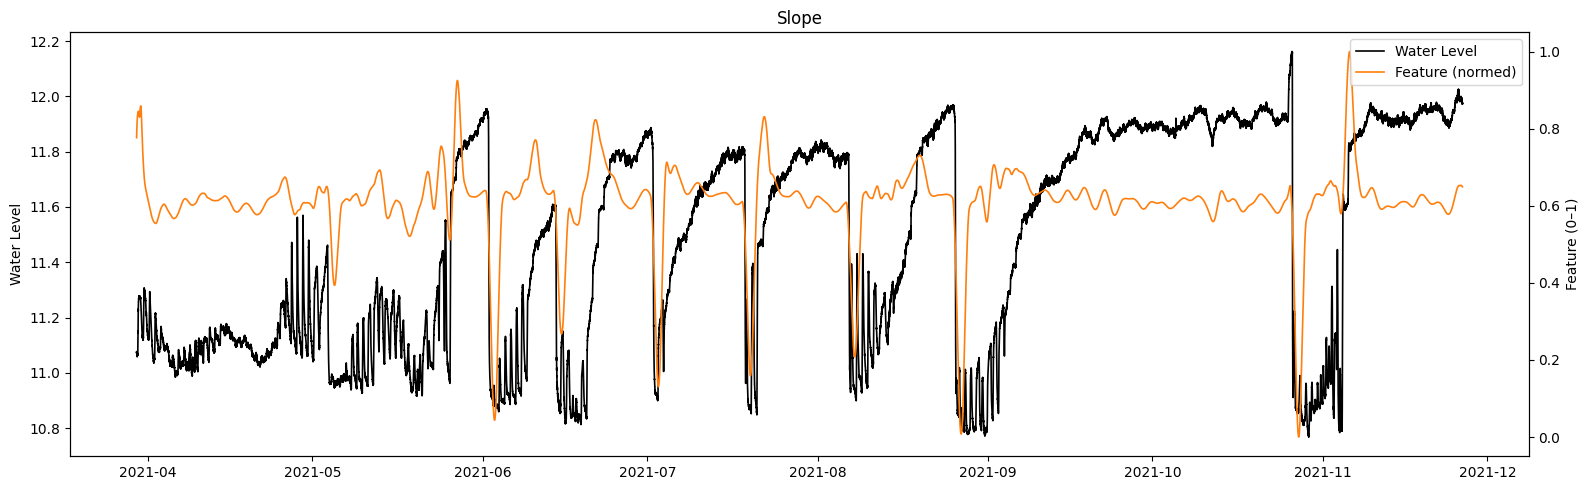

In [350]:
def water_slope(s):
    if len(s) < 5:
        return np.nan
    # slope (linear trend)
    x = s.index.view(int)  # nanoseconds
    y = s.values
    slope = np.polyfit(x, y, 1)[0]

    return slope


d_slope = depth_df.raw_depth.rolling("48h").apply(water_slope).rolling("25h", center=True).mean()

plot_feature_with_depth(depth_df, d_slope, "Slope")

In [357]:
import numpy as np
import pandas as pd


def detect_breach_points(depth_df, rate_threshold=-0.25):
    """
    Detect sharp downward movements indicating breach-like conditions.
    rate_threshold : meters per hour change considered a breach
    """
    s = depth_df["raw_depth"].sort_index()

    var = s.rolling("24h", center=True).var()
    p95 = var.quantile(0.95)
    high_var = var > p95

    # compute rate in m/hr
    dt = np.diff(s.index.values).astype("timedelta64[s]").astype(float) / 3600.0
    ddepth = np.diff(s.values)
    rate = np.empty_like(s.values, dtype=float)
    rate[:] = np.nan
    rate[1:] = ddepth / dt

    rate_series = pd.Series(rate, index=s.index, name="rate_m_per_hr")
    breach_mask = (rate_series < rate_threshold) & high_var
    return breach_mask, rate_series


breach_mask, rate_series = detect_breach_points(depth_df, rate_threshold=-0.25)


def expand_breach_windows(breach_mask, pad="24h"):
    """
    Expand breach points into a window around each breach time.
    pad : str, e.g. '6H', '12H'
    """
    idx = breach_mask[breach_mask].index
    if len(idx) == 0:
        return pd.Series(False, index=breach_mask.index)

    # Start with all False
    expanded = pd.Series(False, index=breach_mask.index)

    half_pad = pd.Timedelta(pad) / 2
    for t in idx:
        start = t - half_pad
        end = t + half_pad
        expanded.loc[start:end] = True

    return expanded

In [363]:
breach_mask, rate_series = detect_breach_points(depth_df, rate_threshold=-0.25)
breach_window_mask = expand_breach_windows(breach_mask, pad="24h")

# Example: using rms_tidal as your tidal-strength feature
rms_tidal[breach_window_mask] = 0.0

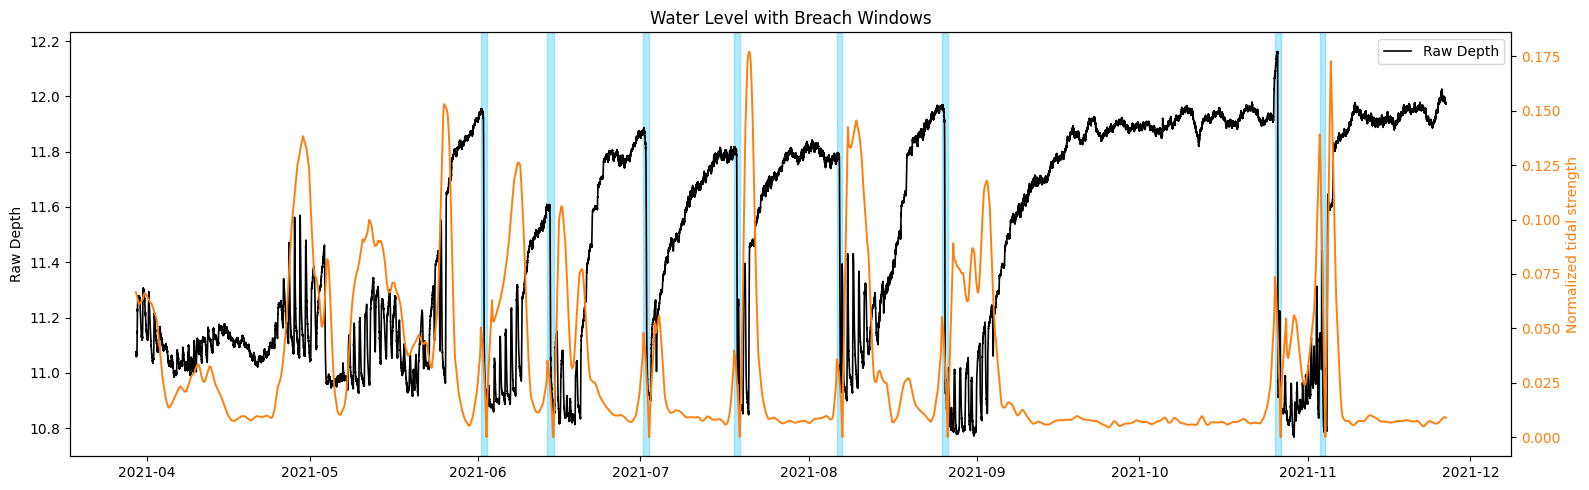

In [365]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_breach_windows(
    depth_df, tidal, breach_window_mask, title="Water Level with Breach Windows"
):
    """
    Plot raw water level with breach windows highlighted as blue bars (vertical spans).

    depth_df : DataFrame with DateTimeIndex and column 'raw_depth'
    breach_window_mask : Series[bool] indexed the same as depth_df
    """
    fig, ax = plt.subplots(figsize=(16, 5))

    # --- Raw water level ---
    ax.plot(depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Raw Depth")

    # --- Identify continuous breach segments ---
    mask = breach_window_mask.fillna(False)
    if mask.any():
        # group consecutive True values
        grp = (mask != mask.shift()).cumsum()
        for g, df_g in mask.groupby(grp):
            if df_g.iloc[0] == True:
                start = df_g.index[0]
                end = df_g.index[-1]
                # shade this range
                ax.axvspan(start, end, color="deepskyblue", alpha=0.3)

    # tidal strength (masked)
    ax2 = ax.twinx()
    ax2.plot(tidal.index, tidal.values, color="C1", linewidth=1.4, label="Tidal strength (masked)")
    ax2.set_ylabel("Normalized tidal strength", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")
    # ax2.set_ylim(-0.05, 1.05)

    ax.set_ylabel("Raw Depth")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_breach_windows(depth_df, rms_tidal.rolling("24h").mean(), breach_window_mask)

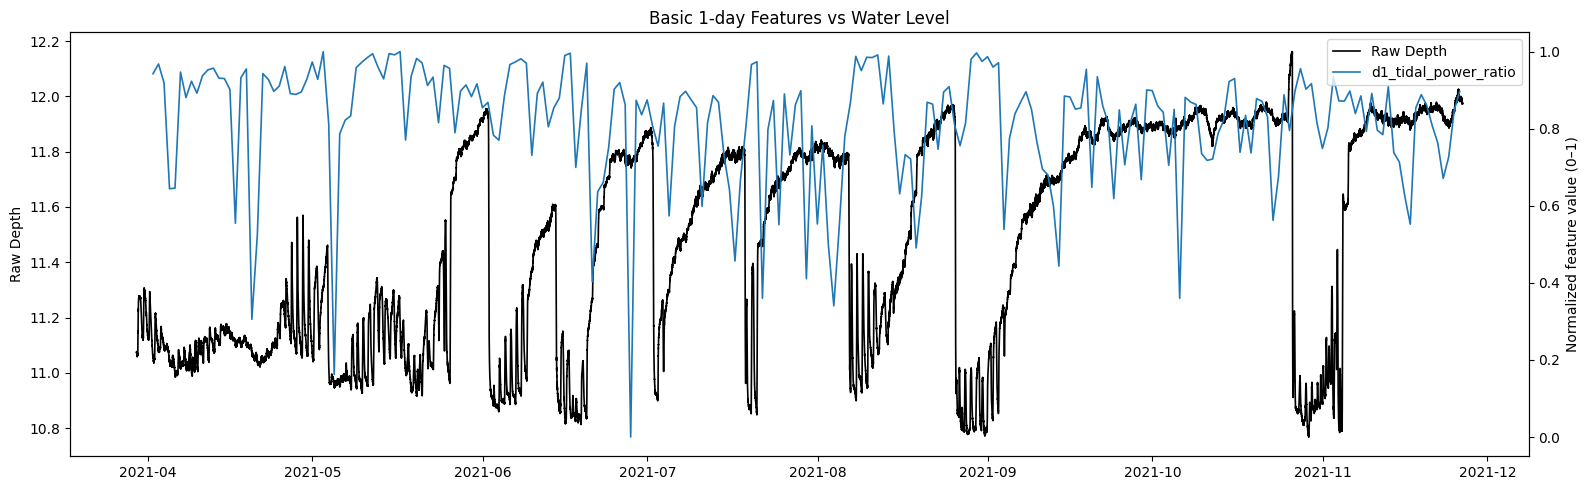

In [82]:
# Suppose combined_features is your concatenated 1D + 3D features
cf = daily_features  # or features_1d / cluster_daily, etc.

cols = []
for pre in ["d1"]:  # , "d3"]:
    cols.extend(
        [
            f"{pre}_tidal_power_ratio",
            # f"{pre}_turning_points",
            # f"{pre}_acf_6h",
            # f"{pre}_acf_12h",
            # f"{pre}_acf_24h",
        ]
    )

plot_features_with_depth(
    depth_df, cf, feature_cols=cols, title="Basic 1-day Features vs Water Level"
)

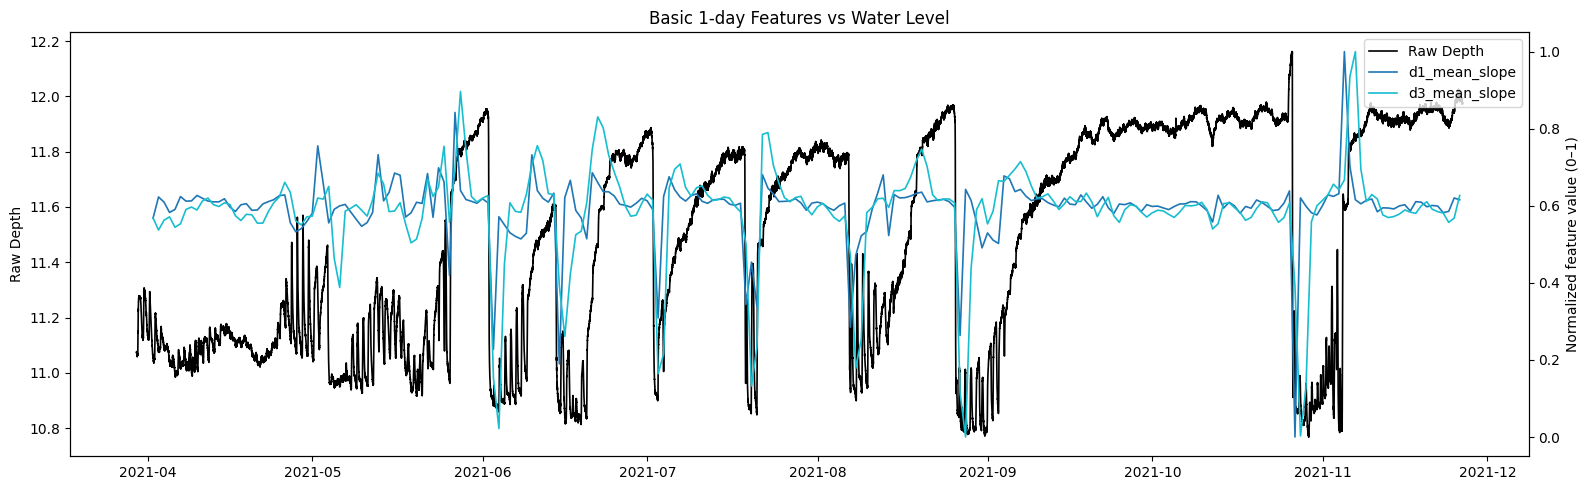

In [81]:
# Suppose combined_features is your concatenated 1D + 3D features
cf = daily_features  # or features_1d / cluster_daily, etc.

cols = []
for pre in ["d1", "d3"]:
    cols.extend(
        [
            # f"{pre}_range",
            # f"{pre}_variance",
            f"{pre}_mean_slope",
            # f"{pre}_abs_deriv_mean",
            # f"{pre}_abs_deriv_max",
            # f"{pre}_median_offset",
        ]
    )

plot_features_with_depth(
    depth_df, cf, feature_cols=cols, title="Basic 1-day Features vs Water Level"
)

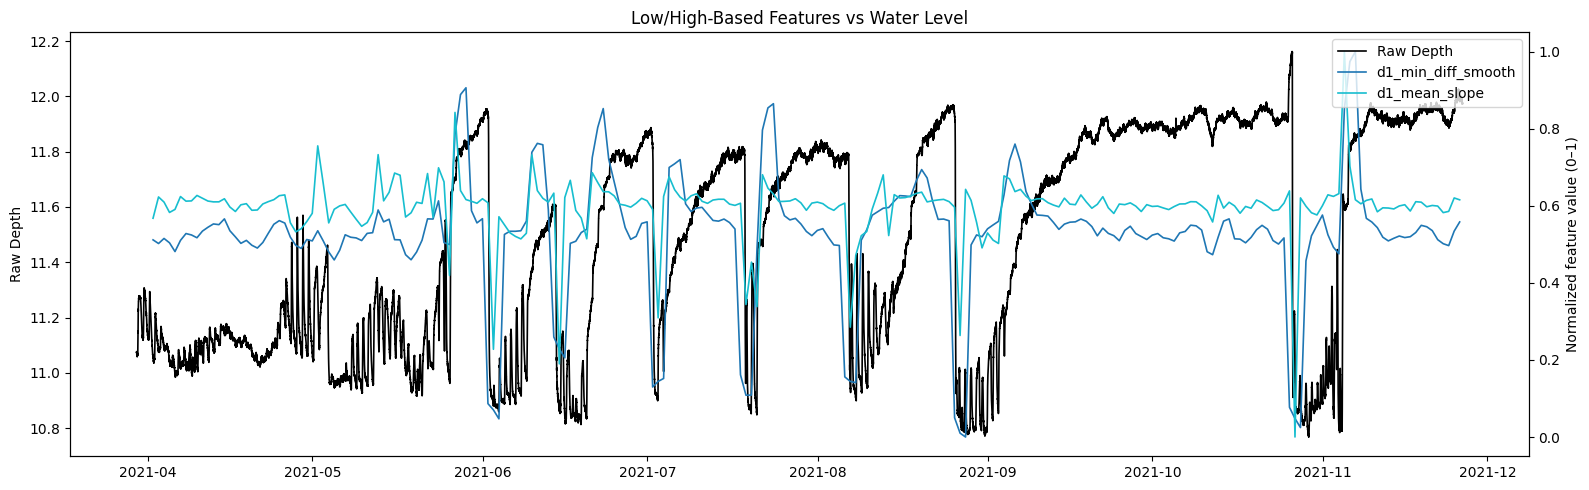

In [86]:
lowhigh_cols = [
    # "d1_win_min",
    # "d1_win_max",
    "d1_min_diff_smooth",
    "d1_mean_slope",
    # "d1_max_minus_prev_min",
]
cf = daily_features

plot_features_with_depth(
    depth_df, cf, feature_cols=lowhigh_cols, title="Low/High-Based Features vs Water Level"
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop rows where features are missing
features_clean = daily_features.dropna().copy()

# Standardize feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

# Keep index for plotting later
feature_index = features_clean.index

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Number of clusters to try
n_clusters = 3

# --- KMeans ---
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
kmeans_labels = kmeans.fit_predict(X_scaled)

# --- Gaussian Mixture Model ---
gmm = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Add labels back into a DataFrame for easier plotting
cluster_results = cluster_daily = pd.DataFrame(
    {
        "acquired": feature_index,
        "kmeans_label": kmeans_labels,
        "gmm_label": gmm_labels,
    }
).set_index("acquired")

cluster_results.head(3)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Ensure predictions have datetime and are sorted ---
pred = predictions.copy()
pred["acquired"] = pd.to_datetime(pred["acquired"])
pred = pred.sort_values("acquired")

# --- Align daily depth values to cluster_daily index (nearest sample) ---
depth_daily = depth_df["raw_depth"].reindex(cluster_daily.index, method="nearest")

fig, ax_depth = plt.subplots(figsize=(16, 6))

# 1. Full water depth time series (left axis)
ax_depth.plot(
    depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Raw Depth"
)
ax_depth.set_ylabel("Raw Depth", color="black")
ax_depth.tick_params(axis="y", labelcolor="black")

# 2. Daily cluster states as colored markers (using GMM labels here)
label_col = "gmm_label"  # or "kmeans_label" if you prefer

unique_clusters = sorted(cluster_daily[label_col].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for cid, color in zip(unique_clusters, colors):
    mask = cluster_daily[label_col] == cid
    ax_depth.scatter(
        cluster_daily.index[mask],
        depth_daily[mask],  # daily depth aligned to cluster time
        s=60,
        color=color,
        alpha=0.9,
        edgecolor="none",
        label=f"Cluster {cid}",
    )

# 3. Second y-axis for prediction probabilities
ax_pred = ax_depth.twinx()
ax_pred.scatter(
    pred["acquired"],
    pred["y_prob"],
    color="C3",
    s=80,
    alpha=0.99,
    marker="+",
    label="Prediction Probability",
)
ax_pred.set_ylabel("Predicted Probability", color="C3")
ax_pred.tick_params(axis="y", labelcolor="C3")

# Title and combined legend
plt.title("Water Level with Daily Cluster States and Model Predictions")

lines1, labels1 = ax_depth.get_legend_handles_labels()
lines2, labels2 = ax_pred.get_legend_handles_labels()
ax_depth.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Inverse transform cluster centers back into original feature units
km_centers_scaled = kmeans.cluster_centers_
km_centers = scaler.inverse_transform(km_centers_scaled)

cluster_centroids_km = pd.DataFrame(km_centers, columns=features_clean.columns)
cluster_centroids_km.index.name = "cluster"

cluster_centroids_km

In [ ]:
pred = predictions.copy()
pred["acquired"] = pd.to_datetime(pred["acquired"])
pred = pred.set_index("acquired").sort_index()

pred = pred[(pred.index >= cluster_daily.index.min()) & (pred.index <= cluster_daily.index.max())]

# choose the probability column name
prob_col = "y_prob" if "y_prob" in pred.columns else "y_pred"

# binary predictions at prediction times only
y_pred_binary = (pred[prob_col] > 0.5).astype(int)

In [ ]:
cluster_to_state = {
    0: 1,
    1: 0,
}
# map cluster IDs to binary open/closed state
y_cluster_state_daily = cluster_daily["gmm_label"].map(cluster_to_state).astype(int)

# align cluster state to prediction timestamps (no new rows!)
y_cluster_at_pred = y_cluster_state_daily.reindex(y_pred_binary.index, method="nearest")

In [ ]:
# both indexed by prediction timestamps
y_true = y_cluster_at_pred  # "truth" from water-level clustering
y_hat = y_pred_binary  # your model predictions

In [ ]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

mask_valid = ~y_true.isna()
y_true_valid = y_true[mask_valid]
y_hat_valid = y_hat[mask_valid]

acc = accuracy_score(y_true_valid, y_hat_valid)
bacc = balanced_accuracy_score(y_true_valid, y_hat_valid)
prec = precision_score(y_true_valid, y_hat_valid)
rec = recall_score(y_true_valid, y_hat_valid)
f1 = f1_score(y_true_valid, y_hat_valid)
cm = confusion_matrix(y_true_valid, y_hat_valid)

print("N points:", len(y_true_valid))
print("Accuracy:", acc)
print("Balanced Accuracy:", bacc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("Confusion Matrix:\n", cm)

In [ ]:
mismatch = y_true != y_hat
mmm = pred[mismatch]

In [ ]:
i = 1
row = mmm.iloc[i]
row_clust = y_true[mismatch].iloc[i]
plt.figure()
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

plt.axis("off")
plt.imshow(img)
_ = plt.title(f"{row.y_pred} {row.date}")

In [ ]:
import numpy as np
import pandas as pd


def detect_openings(
    depth_df,
    drop_threshold_m_per_hr=-0.3,
    smooth_window="30min",
    min_consecutive_points=2,
    pre_window="2D",
    post_delay="2D",
    post_window="1D",
    min_total_drop=0.3,
):
    """
    Detect opening (breach) events from water-level time series.

    Criteria:
      1) Sharp negative drop in smoothed rate (m/hr).
      2) Pre-event water level is high (max over pre_window).
      3) Post-event water level (post_delay + post_window) is still lower
         than pre-event high by at least min_total_drop.

    Parameters
    ----------
    depth_df : DataFrame
        DateTimeIndex and column 'raw_depth'.
    drop_threshold_m_per_hr : float
        Threshold for strong negative rate of change (m/hr).
    smooth_window : str
        Rolling window for smoothing derivative (e.g. '30min', '1H').
    min_consecutive_points : int
        Minimum consecutive points below threshold for a candidate event.
    pre_window : str
        Look-back window before event to compute pre-event high.
    post_delay : str
        Wait time after event before checking post-event level (e.g. '2D').
    post_window : str
        Window after post_delay to compute post-event low (use median).
    min_total_drop : float
        Minimum difference (pre_high - post_level) to accept as real opening.

    Returns
    -------
    events_df : DataFrame
        Columns:
          - event_time
          - min_rate_m_per_hr
          - pre_high
          - post_level
          - total_drop
    """

    df = depth_df.copy().sort_index()
    depth = df["raw_depth"]

    # 1. Compute rate of change in m/hr
    dt = np.diff(depth.index.values).astype("timedelta64[s]").astype(float) / 3600.0  # hours
    ddepth = np.diff(depth.values)
    rate = np.empty_like(depth.values, dtype=float)
    rate[:] = np.nan
    rate[1:] = ddepth / dt

    rate_series = pd.Series(rate, index=depth.index, name="rate_m_per_hr")

    # 2. Smooth the rate
    rate_smooth = rate_series.rolling(smooth_window, min_periods=1, center=True).mean()

    # 3. Flag strong negative drops
    drop_mask = rate_smooth < drop_threshold_m_per_hr

    # 4. Group contiguous drops into candidate events
    grp_id = (drop_mask != drop_mask.shift()).cumsum()
    group_sizes = drop_mask.groupby(grp_id).sum()
    candidate_groups = group_sizes[group_sizes >= min_consecutive_points].index

    event_records = []

    for g in candidate_groups:
        mask = (grp_id == g) & drop_mask
        if not mask.any():
            continue

        # time of steepest drop within this group
        group_rates = rate_smooth[mask]
        min_idx = group_rates.idxmin()
        min_val = group_rates.min()

        # 5. Pre-event high level over pre_window
        pre_start = min_idx - pd.Timedelta(pre_window)
        pre_slice = depth.loc[pre_start:min_idx]
        if len(pre_slice) < 2:
            continue
        pre_high = pre_slice.max()

        # 6. Post-event level: look starting after post_delay for post_window
        post_start = min_idx + pd.Timedelta(post_delay)
        post_end = post_start + pd.Timedelta(post_window)
        post_slice = depth.loc[post_start:post_end]
        if len(post_slice) < 2:
            continue
        post_level = post_slice.min()

        total_drop = pre_high - post_level

        # 7. Accept only if persistent drop is large enough
        if total_drop >= min_total_drop:
            event_records.append(
                {
                    "event_time": min_idx,
                    "min_rate_m_per_hr": float(min_val),
                    "pre_high": float(pre_high),
                    "post_level": float(post_level),
                    "total_drop": float(total_drop),
                }
            )

    if not event_records:
        return pd.DataFrame(
            columns=["event_time", "min_rate_m_per_hr", "pre_high", "post_level", "total_drop"]
        )

    events_df = pd.DataFrame(event_records).sort_values("event_time").reset_index(drop=True)
    return events_df

In [ ]:
events_df = detect_openings(
    depth_df,
    drop_threshold_m_per_hr=-0.15,  # tune for your site
    smooth_window="30min",
    min_consecutive_points=2,
    pre_window="2D",
    post_delay="2D",
    post_window="1D",
    min_total_drop=0.5,  # e.g. 30 cm sustained drop
)

events_df

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(depth_df.index, depth_df["raw_depth"], color="black", linewidth=1.2, label="Raw Depth")

if not events_df.empty:
    ax.scatter(
        events_df["event_time"],
        depth_df["raw_depth"].reindex(events_df["event_time"], method="nearest"),
        color="red",
        s=60,
        label="Detected Opening",
        zorder=5,
    )

ax.set_ylabel("Raw Depth")
ax.set_title("Water Level with Detected Opening Events")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def detect_closures_from_lows(
    low_tide,
    lookback="5D",
    creep_threshold=0.05,  # meters the lows must rise above recent minimum
    min_consecutive=2,  # consecutive lows above threshold
):
    """
    Detect closures based on upward creep in low-tide minima.

    Parameters
    ----------
    low_tide : Series
        Time series of low-tide values (e.g. 6h or daily minima).
    lookback : str
        Window over which to compute the recent minimum low (baseline).
    creep_threshold : float
        Minimum rise above recent min to flag as "creep" (closure signal).
    min_consecutive : int
        Minimum number of consecutive low_tide points above threshold.

    Returns
    -------
    closures_df : DataFrame with 'closure_time' and 'creep_amount'.
    """

    lt = low_tide.sort_index()

    # Recent baseline = rolling minimum over lookback period
    recent_min = lt.rolling(lookback, min_periods=1).min()

    # Creep amount = how much higher current low is than recent min
    creep = lt - recent_min

    # Condition: creep above threshold
    creep_mask = creep > creep_threshold

    # Group consecutive True values
    grp = (creep_mask != creep_mask.shift()).cumsum()
    group_sizes = creep_mask.groupby(grp).sum()

    closures = []
    for g, count in group_sizes.items():
        if count < min_consecutive:
            continue
        mask = (grp == g) & creep_mask
        # define closure time as first time this sustained creep appears
        t0 = lt.index[mask][0]
        closures.append({"closure_time": t0, "creep_amount": float(creep.loc[t0])})

    if not closures:
        return pd.DataFrame(columns=["closure_time", "creep_amount"])

    return pd.DataFrame(closures)

In [ ]:
low_tide = depth_df["raw_depth"].rolling("12h", min_periods=1).min().resample("12h").min().dropna()

high_tide = depth_df["raw_depth"].rolling("12h", min_periods=1).max().resample("12h").max().dropna()

closures_df = detect_closures_from_lows(
    low_tide,
    lookback="5D",
    creep_threshold=0.05,  # 5 cm creep over recent minimum
    min_consecutive=2,
)

closures_df

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

# ax.plot(high_tide.index, high_tide, color="black", linewidth=1.2)

# ax.plot(low_tide.index, low_tide, color="green", linewidth=1.2)

tide_off = high_tide - low_tide

ax.plot(tide_off.index, tide_off, color="green", linewidth=1.2)

if not closures_df.empty:
    ax.scatter(
        closures_df["closure_time"],
        tide_off.reindex(closures_df["closure_time"], method="nearest"),
        color="blue",
        s=80,
        label="Detected Closure",
        zorder=5,
    )

if not events_df.empty:
    ax.scatter(
        events_df["event_time"],
        tide_off.reindex(events_df["event_time"], method="nearest"),
        color="red",
        s=60,
        label="Detected Opening",
        zorder=5,
    )

# ax.set_ylabel("Depth")
# ax.set_title("Detected Closures via Rising Minima")
ax.legend()
plt.show()